In [1]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [2]:
# ── data loading cell ─────────────────────────────────────────────────────────
train  = pd.read_csv("../data/processed/train.csv")
test   = pd.read_csv("../data/processed/test.csv")
val    = pd.read_csv("../data/processed/val.csv")
scaler = jl.load("../models/scaler.pkl")

features = [
    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos",
    "isOutbreak"
]
target = "cases"

xTrain = train[features]
xTest  = test[features]
xVal   = val[features].copy()
yTrain = train[target]
yTest  = test[target]
yVal   = val["cases"].copy()

# wrap in DataFrame to preserve feature names — fixes the warning
xTrainScaled = pd.DataFrame(scaler.transform(xTrain), columns=features)
xValScaled   = pd.DataFrame(scaler.transform(xVal),   columns=features)
xTestScaled  = pd.DataFrame(scaler.transform(xTest),  columns=features)

In [5]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    meanSquareError=mean_squared_error(yTest, predictions)
    r2=r2_score(yTest, predictions)
    rootMeanSquareError=root_mean_squared_error(yTest, predictions)
    meanAbsoluteError=mean_absolute_error(yTest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [48]:
# Linear Regression as baseline model

linearRegression = LinearRegression()
linearRegression.fit(xTrainScaled, yTrain)

timeCv = TimeSeriesSplit(n_splits=5)
cvScore = cross_val_score(linearRegression, xTrainScaled, yTrain, cv=timeCv, scoring='r2')
print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")

# ── val 2019 (outbreak) ───────────────────────────────────────────────────────
yValLr = val["cases"].copy()
print("\n=== Val 2019 (outbreak) ===")
linearEvaluationsVal = regressorEvaluation(linearRegression, xValScaled, yValLr)

# ── test 2020 (final) ─────────────────────────────────────────────────────────
print("\n=== Test 2020 (final) ===")
linearEvaluations = regressorEvaluation(linearRegression, xTestScaled, yTest)

jl.dump(linearRegression, "../models/linear_baseline.pkl")

Cross Validation Average R2 Score: 0.6399
Cross Validation R2 Scores Std: 0.0646
Mean: 0.6399 ± 0.0646

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.6204654728580135
Mean Squared Error: 408.06542216538446
Root Mean Squared Error: 20.200629251718485
Mean Absolute Error: 8.5705148792375

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.42171250081424505
Mean Squared Error: 7.058476371716559
Root Mean Squared Error: 2.6567793231122074
Mean Absolute Error: 1.94540202996665


['../models/linear_baseline.pkl']

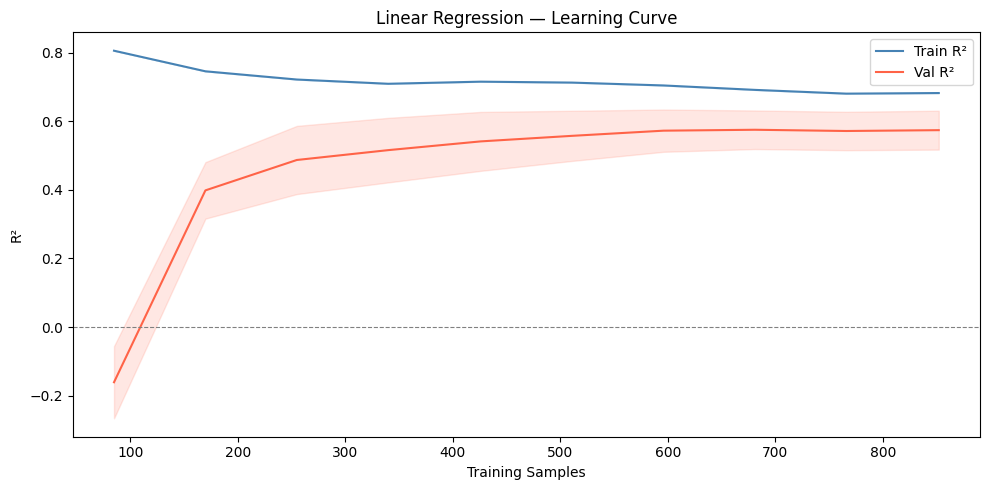

Final train R²: 0.6827 ± 0.0000
Final val   R²: 0.5744 ± 0.0568
Gap:            0.1083


In [50]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

trainSizes, trainScores, valScores = learning_curve(
    linearRegression, xTrainScaled, yTrain,
    cv=TimeSeriesSplit(n_splits=5),   # consistent with RF and XGBoost
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train R²", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val R²", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Linear Regression — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R²: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R²: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, learning_curve
import matplotlib.pyplot as plt
import numpy as np

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetRf = "cases"

xTrainRf = train[featuresRf]
xValRf   = val[featuresRf].copy()
xTestRf  = test[featuresRf].copy()
yTrainRf = train[targetRf]
yValRf   = val[targetRf].copy()
yTestRf  = test[targetRf].copy()

gridParameters = {
    'max_depth':         [7, 8, 9],
    'min_samples_leaf':  [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'max_features':      [0.6, 0.7, 0.8],
    'max_samples':       [0.8, 0.9],
}

tCsv = TimeSeriesSplit(n_splits=5)

gridSearch = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    param_grid=gridParameters,
    cv=tCsv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gridSearch.fit(xTrainRf, yTrainRf)

print(f"Best params: {gridSearch.best_params_}")
print(f"Best CV R²:  {gridSearch.best_score_:.4f}")

rfModel = gridSearch.best_estimator_

scores = cross_val_score(rfModel, xTrainRf, yTrainRf, cv=tCsv, scoring='r2')
print(f"CV Mean: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(rfModel, xValRf, yValRf)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(rfModel, xTestRf, yTestRf)

# feature importance
importance = pd.Series(rfModel.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

jl.dump(rfModel, "../models/rf_regressor.pkl")
print("Saved → ../models/rf_regressor.pkl")

# ── learning curve ────────────────────────────────────────────────────────────
trainSizes, trainScores, valScores = learning_curve(
    rfModel, xTrainRf, yTrainRf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train RMSE", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val RMSE", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("RMSE")
plt.title("Random Forest — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R2: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R2: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'max_depth': 9, 'max_features': 0.8, 'max_samples': 0.9, 'min_samples_leaf': 6, 'min_samples_split': 10}
Best CV R²:  0.7420
CV Mean: 0.7420 ± 0.1781

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.19697096298780759
Mean Squared Error: 863.3954477529046
Root Mean Squared Error: 29.383591471311068
Mean Absolute Error: 11.076047176417362

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8915666304345534
Mean Squared Error: 1.3235188000103457
Root Mean Squared Error: 1.1504428712501746
Mean Absolute Error: 0.7154199687976687

Feature importances:
momentum            0.3422
t1_cases            0.3079
month_sin           0.1020
t2_cases            0.0961
week_cos            0.0925
T2M_lag1            0.0093
T2M_mean            0.0092
isOutbreak          0.0082
PRECTOTCORR_lag2    0.0082
WS10M_mean          0.0051
RH2M_mean           0.0048
district_encoded    0.00

InvalidParameterError: The 'scoring' parameter of learning_curve must be a str among {'jaccard', 'jaccard_macro', 'adjusted_rand_score', 'neg_mean_squared_error', 'neg_root_mean_squared_log_error', 'precision_samples', 'v_measure_score', 'homogeneity_score', 'recall_micro', 'rand_score', 'mutual_info_score', 'top_k_accuracy', 'adjusted_mutual_info_score', 'precision_macro', 'f1_macro', 'neg_mean_absolute_error', 'neg_mean_squared_log_error', 'positive_likelihood_ratio', 'neg_log_loss', 'roc_auc', 'f1_samples', 'neg_mean_gamma_deviance', 'neg_root_mean_squared_error', 'precision_weighted', 'neg_max_error', 'neg_negative_likelihood_ratio', 'recall_weighted', 'r2', 'recall_samples', 'neg_mean_poisson_deviance', 'roc_auc_ovo', 'explained_variance', 'neg_median_absolute_error', 'f1_weighted', 'normalized_mutual_info_score', 'roc_auc_ovr', 'balanced_accuracy', 'd2_brier_score', 'f1_micro', 'precision', 'matthews_corrcoef', 'recall', 'jaccard_samples', 'roc_auc_ovr_weighted', 'recall_macro', 

[0]	validation_0-rmse:3.99240	validation_1-rmse:3.52179
[100]	validation_0-rmse:1.65357	validation_1-rmse:1.44307
[200]	validation_0-rmse:1.30658	validation_1-rmse:1.20981
[300]	validation_0-rmse:1.14496	validation_1-rmse:1.17660
[400]	validation_0-rmse:1.02630	validation_1-rmse:1.14787
[500]	validation_0-rmse:0.94500	validation_1-rmse:1.12558
[592]	validation_0-rmse:0.88224	validation_1-rmse:1.14263
Best iteration: 542
Best val RMSE:  1.1247
CV Mean: 0.7132 ± 0.1952

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.21972203254699707
Mean Squared Error: 838.9341430664062
Root Mean Squared Error: 28.964359283447266
Mean Absolute Error: 11.16681957244873

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8334460258483887
Mean Squared Error: 2.032928466796875
Root Mean Squared Error: 1.4258079528808594
Mean Absolute Error: 0.9305517673492432


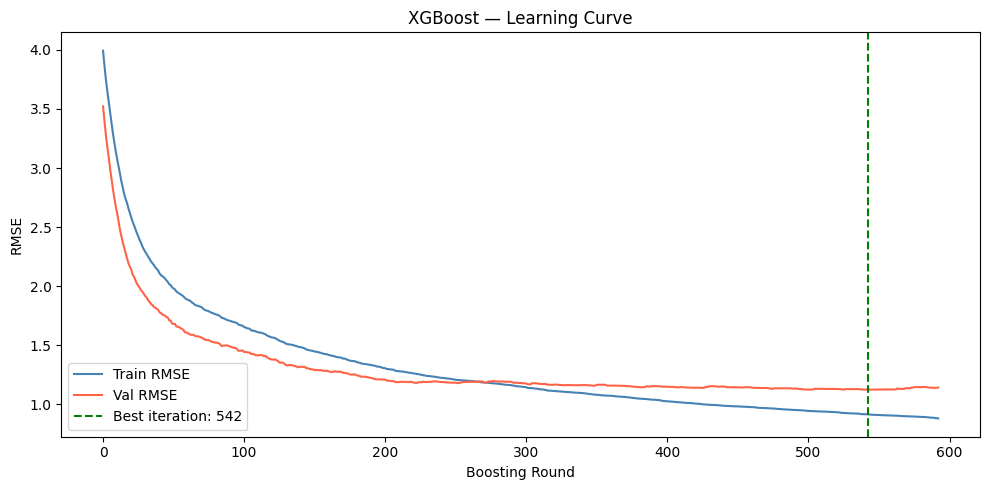

['../models/xgboost_regressor.pkl']

In [73]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor as xgBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"

xTrainXg = train[featuresXg]
xValXg   = val[featuresXg].copy()
xTestXg  = test[featuresXg].copy()
yTrainXg = train[targetXg]
yValXg   = val[targetXg].copy()
yTestXg  = test[targetXg].copy()

# early stopping split — last fold of TimeSeriesSplit
tCsv   = TimeSeriesSplit(n_splits=5)
splits = list(tCsv.split(xTrainXg))
trainIdx, valIdx = splits[-1]

xEarlySplit = xTrainXg.iloc[trainIdx]
yEarlySplit = yTrainXg.iloc[trainIdx]
xValSplit   = xTrainXg.iloc[valIdx]
yValSplit   = yTrainXg.iloc[valIdx]

xgModel = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgModel.fit(
    xEarlySplit, yEarlySplit,
    eval_set=[
        (xEarlySplit, yEarlySplit),
        (xValSplit,   yValSplit)
    ],
    verbose=100
)

print(f"Best iteration: {xgModel.best_iteration}")
print(f"Best val RMSE:  {xgModel.best_score:.4f}")

# CV with fixed n_estimators
xgModelCv = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=xgModel.best_iteration,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgScores = cross_val_score(xgModelCv, xTrainXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"CV Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(xgModel, xValXg, yValXg)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(xgModel, xTestXg, yTestXg)

# ── learning curve ────────────────────────────────────────────────────────────
results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

jl.dump(xgModel, "../models/xgboost_regressor.pkl")

In [54]:
# ── Outbreak RF Regressor (2019 only) ────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import joblib as jl

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]

# val = 2019 data (already loaded)
xTrain2019 = val[featuresRf].copy()
yTrain2019 = val["cases"].copy()

print(f"2019 training rows: {len(xTrain2019)}")
print(f"Cases — mean: {yTrain2019.mean():.2f}, max: {yTrain2019.max():.2f}")

# ── train outbreak RF ─────────────────────────────────────────────────────────
# KFold instead of TimeSeriesSplit — only 1 year of data, 
# TimeSeriesSplit would give tiny folds
rfOutbreak = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=0.7,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

rfOutbreak.fit(xTrain2019, yTrain2019)

# ── evaluate on 2019 itself (sanity check) ────────────────────────────────────
print("\n=== Train fit (2019) ===")
regressorEvaluation(rfOutbreak, xTrain2019, yTrain2019)

# ── CV within 2019 ────────────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=False)   # no shuffle — preserve time order
cvScores = cross_val_score(rfOutbreak, xTrain2019, yTrain2019, cv=kf, scoring='r2')
print(f"\nCV Mean: {cvScores.mean():.4f} ± {cvScores.std():.4f}")

# ── how well does it predict 2020 test? ──────────────────────────────────────
print("\n=== Test 2020 (how outbreak model handles normal year) ===")
regressorEvaluation(rfOutbreak, test[featuresRf], test["cases"])

# ── feature importance ────────────────────────────────────────────────────────
importance = pd.Series(rfOutbreak.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

# ── save ──────────────────────────────────────────────────────────────────────
jl.dump(rfOutbreak, "../models/rf_regressor_outbreak.pkl")
print("\nSaved → ../models/rf_regressor_outbreak.pkl")

2019 training rows: 1728
Cases — mean: 17.92, max: 356.00

=== Train fit (2019) ===
The Model Performance metrics are:
R2 Score: 0.9413854364859479
Mean Squared Error: 63.02081864729344
Root Mean Squared Error: 7.938565276376672
Mean Absolute Error: 2.5535604363217526

CV Mean: 0.8957 ± 0.0591

=== Test 2020 (how outbreak model handles normal year) ===
The Model Performance metrics are:
R2 Score: -17.91792275836052
Mean Squared Error: 230.90886622979585
Root Mean Squared Error: 15.195685776884037
Mean Absolute Error: 8.071765023172262

Feature importances:
momentum            0.4703
t1_cases            0.1887
month_sin           0.1800
week_cos            0.0583
t2_cases            0.0442
T2M_mean            0.0155
PRECTOTCORR_lag1    0.0109
PRECTOTCORR_lag2    0.0086
PRECTOTCORR_sum     0.0055
waterProxy          0.0046
T2M_lag1            0.0036
district_encoded    0.0027
WS10M_mean          0.0026
RH2M_mean           0.0023
isOutbreak          0.0022
dtype: float64

Saved → ../model

[0]	validation_0-rmse:32.10912	validation_1-rmse:29.61897


[100]	validation_0-rmse:9.76094	validation_1-rmse:8.54816
[200]	validation_0-rmse:7.67812	validation_1-rmse:8.18822
[300]	validation_0-rmse:6.37307	validation_1-rmse:7.90464
[376]	validation_0-rmse:5.61406	validation_1-rmse:7.85379
Best iteration: 326
Best val RMSE:  7.7876
CV Mean: 0.8003 ± 0.1131

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.9614174365997314
Mean Squared Error: 41.48295593261719
Root Mean Squared Error: 6.440726280212402
Mean Absolute Error: 3.044865369796753

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: -11.770577430725098
Mean Squared Error: 155.87545776367188
Root Mean Squared Error: 12.48500919342041
Mean Absolute Error: 7.46100378036499


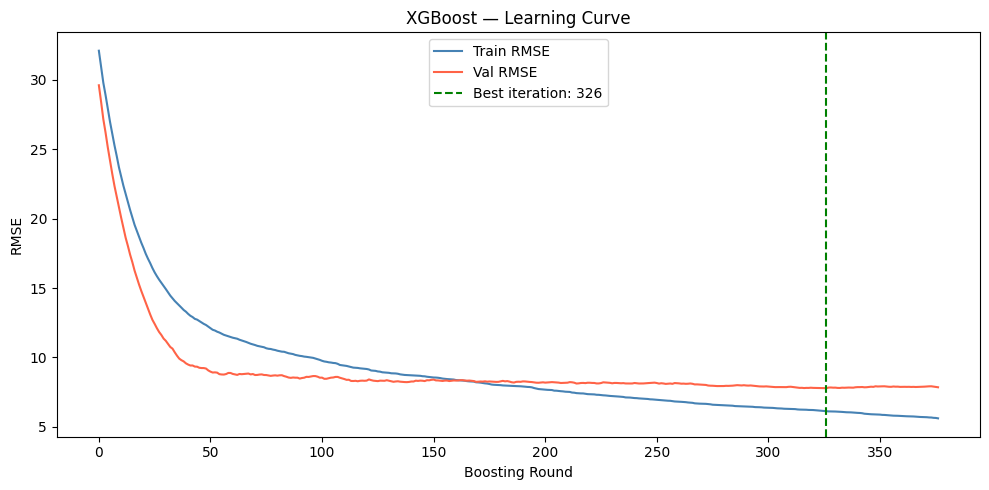

['../models/xgboost_regressor_Outbreak.pkl']

In [60]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor as xgBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"

xTrainXg = val[featuresXg].copy()
yTrainXg   = val[targetXg].copy()

# early stopping split — last fold of TimeSeriesSplit
tCsv   = TimeSeriesSplit(n_splits=5)
splits = list(tCsv.split(xTrainXg))
trainIdx, valIdx = splits[-1]

xEarlySplit = xTrainXg.iloc[trainIdx]
yEarlySplit = yTrainXg.iloc[trainIdx]
xValSplit   = xTrainXg.iloc[valIdx]
yValSplit   = yTrainXg.iloc[valIdx]

xgModel = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgModel.fit(
    xEarlySplit, yEarlySplit,
    eval_set=[
        (xEarlySplit, yEarlySplit),
        (xValSplit,   yValSplit)
    ],
    verbose=100
)

print(f"Best iteration: {xgModel.best_iteration}")
print(f"Best val RMSE:  {xgModel.best_score:.4f}")

# CV with fixed n_estimators
xgModelCv = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=xgModel.best_iteration,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgScores = cross_val_score(xgModelCv, xTrainXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"CV Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(xgModel, xValXg, yValXg)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(xgModel, xTestXg, yTestXg)

# ── learning curve ────────────────────────────────────────────────────────────
results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

jl.dump(xgModel, "../models/xgboost_regressor_Outbreak.pkl")

In [1]:
import pandas as pd
import joblib as jl
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score

# Load Models
endemicModel = jl.load("../models/xgboost_regressor.pkl")
outbreakModel = jl.load("../models/xgboost_regressor_outbreak.pkl")

# Configuration
intensityThreshold = 40

def applyFeatureEngineering(targetDf, referenceDf):
    refStats = referenceDf.groupby('district_encoded')['t1_cases'].agg(['mean','std'])
    targetDf['t1_cases_zscore'] = targetDf.apply(
        lambda r: (r['t1_cases'] - refStats.loc[r['district_encoded'], 'mean']) /
                  (refStats.loc[r['district_encoded'], 'std'] + 1e-6), axis=1
    )
    targetDf['cases_acceleration'] = targetDf.groupby('district_encoded')['momentum'].transform(
        lambda x: x - x.shift(1).fillna(0)
    )
    return targetDf

# Prepare Data
clfTrain = pd.concat([train, val], ignore_index=True)
clfTrain = applyFeatureEngineering(clfTrain, clfTrain)
testData = applyFeatureEngineering(test, clfTrain)
valData = applyFeatureEngineering(val, clfTrain)

# Define Target based on Magnitude
clfTrain['intensityTarget'] = (clfTrain['cases'] > intensityThreshold).astype(int)

classifierFeatures = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", 
    "waterProxy", "t1_cases", "t2_cases", "momentum", 
    "cases_acceleration", "t1_cases_zscore", "month_sin", "week_cos"
]

# Train Magnitude Classifier
magnitudeClassifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
magnitudeClassifier.fit(clfTrain[classifierFeatures], clfTrain['intensityTarget'])

def evaluateHybridSystem(data, yearLabel):
    # Classification Logic
    outbreakProbs = magnitudeClassifier.predict_proba(data[classifierFeatures])[:, 1]
    yPredClass = (outbreakProbs > 0.7).astype(int)
    yTrueClass = (data['cases'] > intensityThreshold).astype(int)
    
    print(f"\n=== {yearLabel} Classifier Performance ===")
    print(classification_report(yTrueClass, yPredClass, zero_division=0))
    
    print(f"Confusion Matrix {yearLabel}:")
    print(confusion_matrix(yTrueClass, yPredClass))
    
    # Regression Logic
    predEndemic = endemicModel.predict(data[features])
    predOutbreak = outbreakModel.predict(data[features])
    
    finalPredictions = []
    for i in range(len(data)):
        if outbreakProbs[i] > 0.7:
            finalPredictions.append(predOutbreak[i])
        else:
            finalPredictions.append(predEndemic[i])
            
    currentMae = mean_absolute_error(data['cases'], finalPredictions)
    currentR2 = r2_score(data['cases'], finalPredictions)
    
    print(f"{yearLabel} Hybrid MAE: {currentMae:.4f}")
    print(f"{yearLabel} Hybrid R²: {currentR2:.4f}")
    
    return finalPredictions

# Execute Evaluation
valResults = evaluateHybridSystem(valData, "2019 Val")
testResults = evaluateHybridSystem(testData, "2020 Test")

# Save the Gatekeeper
jl.dump(magnitudeClassifier, "../models/outbreak_classifier.pkl")

NameError: name 'train' is not defined

In [10]:
import numpy as np
import pandas as pd
import pickle
import warnings

warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
)
import seaborn as sns
import matplotlib.pyplot as plt


# =============================================================================
# DYNAMIC BINNER
# =============================================================================

class DynamicBinner:
    """
    Converts raw dengue case counts into severity labels.

        0 -> Low
        1 -> Medium
        2 -> High
        3 -> Severe

    Thresholds are learned from training data only (no leakage).
    Uses log1p transform to handle right-skewed outbreak data.
    """

    LABEL_NAMES = ["Low", "Medium", "High", "Severe"]

    def __init__(
        self,
        percentiles=(30, 75, 92),
        use_log=True,
        remove_outliers=True,
        outlier_percentiles=(1, 99),
        verbose=True,
    ):
        self.percentiles         = percentiles
        self.use_log             = use_log
        self.remove_outliers     = remove_outliers
        self.outlier_percentiles = outlier_percentiles
        self.verbose             = verbose
        self.thresholds_         = None
        self.bins_               = None

    def _preprocess(self, cases: np.ndarray) -> np.ndarray:
        c = np.array(cases, dtype=float).flatten()
        c = c[c >= 0]
        if self.use_log:
            c = np.log1p(c)
        if self.remove_outliers:
            lo, hi = self.outlier_percentiles
            c = c[(c >= np.percentile(c, lo)) & (c <= np.percentile(c, hi))]
        return c

    def fit(self, cases) -> "DynamicBinner":
        c = self._preprocess(np.array(cases, dtype=float).flatten())

        if len(c) < 10:
            raise ValueError(
                f"Only {len(c)} samples after preprocessing. "
                "Check for all-zero or near-constant input."
            )

        p1, p2, p3 = self.percentiles
        thresholds = sorted(np.percentile(c, p) for p in (p1, p2, p3))

        eps = 1e-3
        for i in range(1, len(thresholds)):
            if thresholds[i] <= thresholds[i - 1]:
                thresholds[i] = thresholds[i - 1] + eps

        t1, t2, t3 = thresholds

        if self.use_log:
            t1, t2, t3 = np.expm1(t1), np.expm1(t2), np.expm1(t3)

        t1, t2, t3 = round(float(t1), 2), round(float(t2), 2), round(float(t3), 2)

        if t2 <= t1: t2 = t1 + 0.01
        if t3 <= t2: t3 = t2 + 0.01

        self.thresholds_ = (t1, t2, t3)
        self.bins_       = [-np.inf, t1, t2, t3, np.inf]

        if self.verbose:
            print("\n[DynamicBinner — Learned Thresholds]")
            for lo, hi, name in zip(self.bins_, self.bins_[1:], self.LABEL_NAMES):
                lo_s = f"{lo:.2f}" if np.isfinite(lo) else "-∞"
                hi_s = f"{hi:.2f}" if np.isfinite(hi) else "+∞"
                print(f"  {name:8s}: ({lo_s}, {hi_s}]")

        return self

    def transform(self, cases, print_dist=False) -> np.ndarray:
        if self.bins_ is None:
            raise RuntimeError("Call fit() before transform().")

        labels = pd.cut(
            pd.Series(np.array(cases).flatten()),
            bins=self.bins_,
            labels=[0, 1, 2, 3],
            include_lowest=True,
        ).astype(int).to_numpy()

        if print_dist and self.verbose:
            unique, counts = np.unique(labels, return_counts=True)
            print("\n[DynamicBinner — Class Distribution]")
            for u, c in zip(unique, counts):
                print(f"  {self.LABEL_NAMES[u]:8s}: {c}")

        return labels

    def fit_transform(self, cases, print_dist=True) -> np.ndarray:
        return self.fit(cases).transform(cases, print_dist=print_dist)

    def save(self, path: str) -> None:
        with open(path, "wb") as f:
            pickle.dump(self, f)
        if self.verbose:
            print(f"[DynamicBinner] Saved -> {path}")

    @staticmethod
    def load(path: str) -> "DynamicBinner":
        with open(path, "rb") as f:
            return pickle.load(f)


LABEL_NAMES = DynamicBinner.LABEL_NAMES
binner = DynamicBinner(percentiles=(30, 78, 92), use_log=True, remove_outliers=True)

# 3. Create the Target Labels (y) for the Classifier to learn from
y_train = binner.fit_transform(train["cases"])
y_test  = binner.transform(test["cases"])

print("\nCell 1 Complete: Binner is fitted and LABEL_NAMES are defined.")



[DynamicBinner — Learned Thresholds]
  Low     : (-∞, 2.00]
  Medium  : (2.00, 5.00]
  High    : (5.00, 9.00]
  Severe  : (9.00, +∞]

[DynamicBinner — Class Distribution]
  Low     : 2640
  Medium  : 1417
  High    : 612
  Severe  : 443

Cell 1 Complete: Binner is fitted and LABEL_NAMES are defined.


=== Endemic Expert Severity Performance (Test Set) ===
              precision    recall  f1-score   support

         Low       0.98      0.71      0.82       981
      Medium       0.54      0.74      0.63       450
        High       0.55      0.79      0.65       191
      Severe       0.74      0.93      0.82       106

    accuracy                           0.74      1728
   macro avg       0.70      0.79      0.73      1728
weighted avg       0.80      0.74      0.75      1728



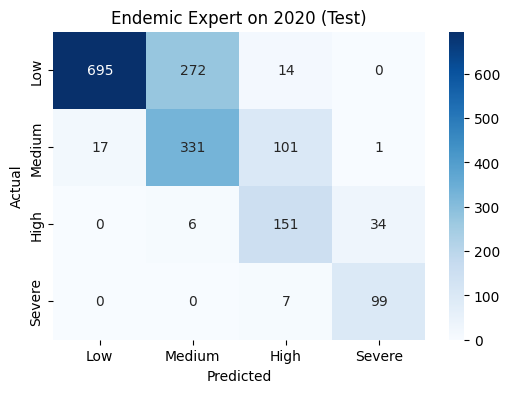

In [11]:
import joblib as jl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuration & Features
REGRESSOR_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "WS10M_mean", "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases", "waterProxy", "month_sin", "week_cos",
    "momentum", "isOutbreak"
]

# 2. Load Models
# Ensure you have your binner object from Cell 1
endemicRegressor = jl.load("../models/rf_regressor.pkl") 

# 3. Generate Features for Classifier
predTestEndemic = np.clip(endemicRegressor.predict(test[REGRESSOR_FEATURES].fillna(0)), 0, None)
xTestHybrid = pd.DataFrame({"pred_cases": predTestEndemic})

# 4. Severity Mapping
yPredEndemicLabels = binner.transform(predTestEndemic)
yTrueTestLabels = binner.transform(test["cases"])

# 5. Evaluation
print("=== Endemic Expert Severity Performance (Test Set) ===")
print(classification_report(yTrueTestLabels, yPredEndemicLabels, target_names=LABEL_NAMES, zero_division=0))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(yTrueTestLabels, yPredEndemicLabels), annot=True, fmt='d', 
            cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Endemic Expert on 2020 (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Outbreak Expert Severity Performance (Combined Train + Val) ===
              precision    recall  f1-score   support

         Low       0.97      0.33      0.49      3253
      Medium       0.27      0.42      0.33      1741
        High       0.27      0.28      0.27       798
      Severe       0.46      0.95      0.62      1048

    accuracy                           0.44      6840
   macro avg       0.49      0.49      0.43      6840
weighted avg       0.63      0.44      0.44      6840



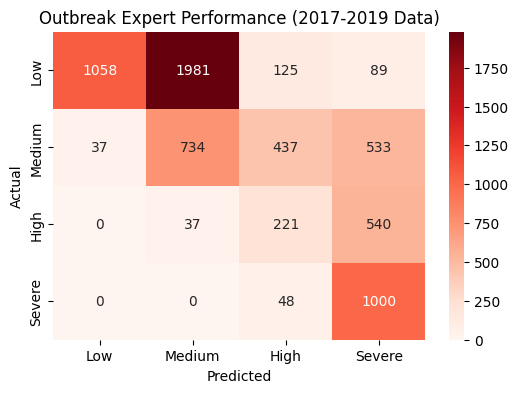

Cell 3 Complete: Prepared 6840 training samples for Cell 4.


In [16]:
import joblib as jl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configuration & Features (Repeated to ensure scope)
REGRESSOR_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "WS10M_mean", "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases", "waterProxy", "month_sin", "week_cos",
    "momentum", "isOutbreak"
]

# 2. Load the Outbreak Expert Model
# This is the specialized XGBoost model trained for high-intensity spikes
outbreakRegressor = jl.load("../models/xgboost_regressor_Outbreak.pkl")

# 3. Combine Train and Val (CRITICAL STEP)
# We merge 2017/2018 (Train) with 2019 (Val) so the classifier sees outbreaks
combined_df = pd.concat([train, val], ignore_index=True)

# 4. Generate Training Features for the Severity Classifier
# We use the Outbreak Expert to predict on the combined data
predTrainOutbreak = np.clip(outbreakRegressor.predict(combined_df[REGRESSOR_FEATURES].fillna(0)), 0, None)

# Create the feature DataFrame for the final Classifier (Cell 4)
xTrainHybrid = pd.DataFrame({"pred_cases": predTrainOutbreak})

# 5. Generate Training Labels
# We must also transform the actual cases from the combined set into (0, 1, 2, 3)
y_train_hybrid = binner.transform(combined_df["cases"])

# 6. Sanity Check Evaluation
# This shows how the Outbreak Expert performs on its own training set
yPredOutbreakLabels = binner.transform(predTrainOutbreak)

print("=== Outbreak Expert Severity Performance (Combined Train + Val) ===")
print(classification_report(y_train_hybrid, yPredOutbreakLabels, 
                            target_names=binner.LABEL_NAMES, zero_division=0))

# 7. Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_train_hybrid, yPredOutbreakLabels), annot=True, fmt='d', 
            cmap='Reds', xticklabels=binner.LABEL_NAMES, yticklabels=binner.LABEL_NAMES)
plt.title("Outbreak Expert Performance (2017-2019 Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Cell 3 Complete: Prepared {len(xTrainHybrid)} training samples for Cell 4.")


==================== FINAL HYBRID SYSTEM EVALUATION (2020) ====================

              precision    recall  f1-score   support

         Low     0.8251    0.9664    0.8901       981
      Medium     0.7319    0.4489    0.5565       450
        High     0.5341    0.7801    0.6340       191
      Severe     0.9167    0.2075    0.3385       106

    accuracy                         0.7645      1728
   macro avg     0.7519    0.6007    0.6048      1728
weighted avg     0.7743    0.7645    0.7411      1728



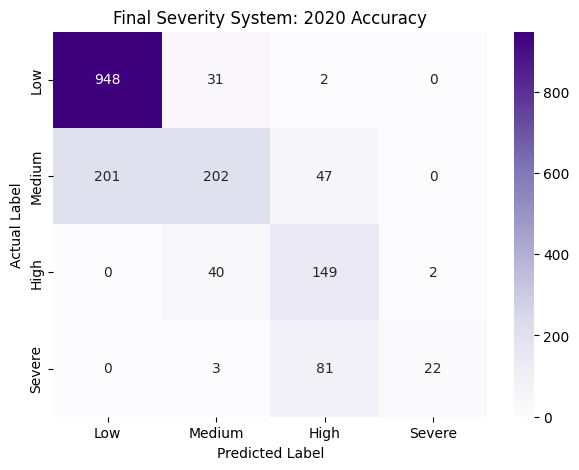

Final System Accuracy: 0.7645
[DynamicBinner] Saved -> ../models/dynamic_binner.pkl


In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Weights (using the hybrid labels from Cell 3)
counts = np.bincount(y_train_hybrid)
weights = len(y_train_hybrid) / (len(counts) * counts)
sampleWeights = np.array([weights[y] for y in y_train_hybrid])

# 2. Train the Severity Classifier
# This model's job is to FIX the over-sensitivity of the Outbreak Expert
severityClf = XGBClassifier(
    n_estimators=500, # Increased for better learning
    max_depth=3,      # Shallow depth to prevent overfitting 2019
    learning_rate=0.03,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

severityClf.fit(
    xTrainHybrid, 
    y_train_hybrid,
    sample_weight=sampleWeights,
    eval_set=[(xTestHybrid, y_test)], # We still validate against the "blind" 2020 year
    verbose=False
)

# 3. Final 2020 Evaluation
yPredFinal = severityClf.predict(xTestHybrid)

print("\n==================== FINAL HYBRID SYSTEM EVALUATION (2020) ====================\n")
print(classification_report(y_test, yPredFinal, target_names=LABEL_NAMES, digits=4))

# 4. Final Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, yPredFinal), annot=True, fmt='d', 
            cmap='Purples', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Final Severity System: 2020 Accuracy")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(f"Final System Accuracy: {accuracy_score(y_test, yPredFinal):.4f}")

binner.save("../models/dynamic_binner.pkl")

with open("../models/severity_classifier.pkl", "wb") as f:
    pickle.dump(severityClf, f)